In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/processed_fraud_data_optimized.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   trans_date_trans_time    555719 non-null  object 
 1   amt                      555719 non-null  float64
 2   lat                      555719 non-null  float64
 3   city_pop                 555719 non-null  int64  
 4   dob                      555719 non-null  object 
 5   unix_time                555719 non-null  int64  
 6   merch_lat                555719 non-null  float64
 7   is_fraud                 555719 non-null  int64  
 8   trans_hour               555719 non-null  int64  
 9   age                      555719 non-null  int64  
 10  gender_M                 555719 non-null  int64  
 11  category_food_dining     555719 non-null  int64  
 12  category_gas_transport   555719 non-null  int64  
 13  category_grocery_net     555719 non-null  int64  
 14  cate

In [ ]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']


In [ ]:
print(X.columns.tolist())

['trans_date_trans_time', 'amt', 'lat', 'city_pop', 'dob', 'unix_time', 'merch_lat', 'trans_hour', 'age', 'gender_M', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'trans_day_of_week', 'is_weekend', 'trans_month', 'log_amt', 'distance_km', 'age_group_18-30', 'age_group_30-45', 'age_group_45-60', 'age_group_60+']


In [ ]:
print(X.dtypes)


trans_date_trans_time       object
amt                        float64
lat                        float64
city_pop                     int64
dob                         object
unix_time                    int64
merch_lat                  float64
trans_hour                   int64
age                          int64
gender_M                     int64
category_food_dining         int64
category_gas_transport       int64
category_grocery_net         int64
category_grocery_pos         int64
category_health_fitness      int64
category_home                int64
category_kids_pets           int64
category_misc_net            int64
category_misc_pos            int64
category_personal_care       int64
category_shopping_net        int64
category_shopping_pos        int64
category_travel              int64
trans_day_of_week            int64
is_weekend                   int64
trans_month                  int64
log_amt                    float64
distance_km                float64
age_group_18-30     

In [ ]:
import pandas as pd

# Load your training dataset
df = pd.read_csv("/content/drive/MyDrive/processed_fraud_data_optimized.csv")  # Replace with your dataset path

# Select one row as a sample input
sample_input = df.iloc[0].to_dict()

# Optionally convert column names to string keys (for JSON)
import json
print(json.dumps(sample_input, indent=2, default=str))



{
  "trans_date_trans_time": "2020-06-21 12:14:25",
  "amt": 2.86,
  "lat": 33.9659,
  "city_pop": 333497,
  "dob": "1968-03-19",
  "unix_time": 1371816865,
  "merch_lat": 33.986391,
  "is_fraud": 0,
  "trans_hour": 12,
  "age": 52,
  "gender_M": 1,
  "category_food_dining": 0,
  "category_gas_transport": 0,
  "category_grocery_net": 0,
  "category_grocery_pos": 0,
  "category_health_fitness": 0,
  "category_home": 0,
  "category_kids_pets": 0,
  "category_misc_net": 0,
  "category_misc_pos": 0,
  "category_personal_care": 1,
  "category_shopping_net": 0,
  "category_shopping_pos": 0,
  "category_travel": 0,
  "trans_day_of_week": 6,
  "is_weekend": 1,
  "trans_month": 6,
  "log_amt": 1.3506671834767394,
  "distance_km": 24.613746071297623,
  "age_group_18-30": 0,
  "age_group_30-45": 0,
  "age_group_45-60": 1,
  "age_group_60+": 0
}


In [ ]:
df.head()

,trans_date_trans_time,amt,lat,city_pop,dob,unix_time,merch_lat,is_fraud,trans_hour,age,...,category_travel,trans_day_of_week,is_weekend,trans_month,log_amt,distance_km,age_group_18-30,age_group_30-45,age_group_45-60,age_group_60+
0,2020-06-21 12:14:25,2.86,33.9659,333497,1968-03-19,1371816865,33.986391,0,12,52,...,0,6,1,6,1.350667,24.613746,0,0,1,0
1,2020-06-21 12:14:33,29.84,40.3207,302,1990-01-17,1371816873,39.450498,0,12,30,...,0,6,1,6,3.428813,104.834043,1,0,0,0
2,2020-06-21 12:14:53,41.28,40.6729,34496,1970-10-21,1371816893,40.495810,0,12,49,...,0,6,1,6,3.744314,59.204796,0,0,1,0
3,2020-06-21 12:15:15,60.05,28.5697,54767,1987-07-25,1371816915,28.812398,0,12,32,...,0,6,1,6,4.111693,27.615117,0,1,0,0
4,2020-06-21 12:15:17,3.19,44.2529,1126,1955-07-06,1371816917,44.959148,0,12,65,...,1,6,1,6,1.432701,104.423175,0,0,0,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [ ]:
X_train = X_train.drop(columns=X_train.select_dtypes(include=['object', 'datetime']).columns)
X_test = X_test.drop(columns=X_test.select_dtypes(include=['object', 'datetime']).columns)

In [ ]:
print("X_train columns and types:\n", X_train.dtypes)
print("X_test columns and types:\n", X_test.dtypes)

X_train columns and types:
 amt                        float64
lat                        float64
city_pop                     int64
unix_time                    int64
merch_lat                  float64
trans_hour                   int64
age                          int64
gender_M                     int64
category_food_dining         int64
category_gas_transport       int64
category_grocery_net         int64
category_grocery_pos         int64
category_health_fitness      int64
category_home                int64
category_kids_pets           int64
category_misc_net            int64
category_misc_pos            int64
category_personal_care       int64
category_shopping_net        int64
category_shopping_pos        int64
category_travel              int64
trans_day_of_week            int64
is_weekend                   int64
trans_month                  int64
log_amt                    float64
distance_km                float64
age_group_18-30              int64
age_group_30-45            

In [ ]:
df.columns

Index(['trans_date_trans_time', 'amt', 'lat', 'city_pop', 'dob', 'unix_time',
       'merch_lat', 'is_fraud', 'trans_hour', 'age', 'gender_M',
       'category_food_dining', 'category_gas_transport',
       'category_grocery_net', 'category_grocery_pos',
       'category_health_fitness', 'category_home', 'category_kids_pets',
       'category_misc_net', 'category_misc_pos', 'category_personal_care',
       'category_shopping_net', 'category_shopping_pos', 'category_travel',
       'trans_day_of_week', 'is_weekend', 'trans_month', 'log_amt',
       'distance_km', 'age_group_18-30', 'age_group_30-45', 'age_group_45-60',
       'age_group_60+'],
      dtype='object')

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_res, y_train_res)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:58:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.66      0.85      0.75       644

    accuracy                           1.00    166716
   macro avg       0.83      0.93      0.87    166716
weighted avg       1.00      1.00      1.00    166716

Confusion Matrix:
 [[165791    281]
 [    94    550]]
ROC AUC Score: 0.9957152368096573


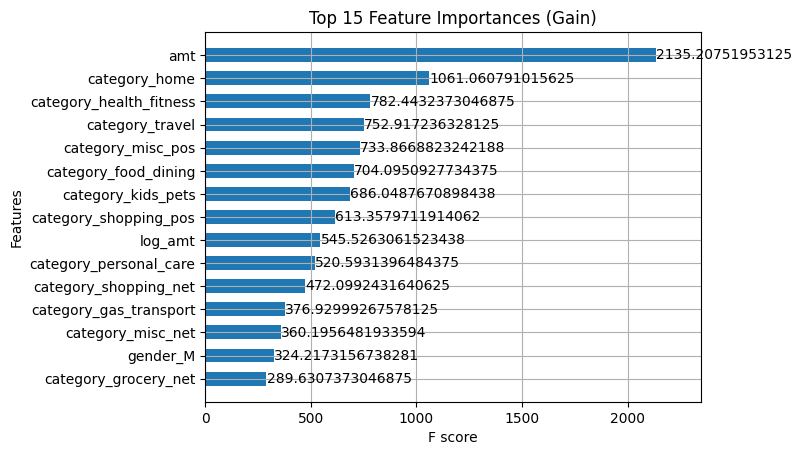

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

xgb.plot_importance(model, importance_type='gain', max_num_features=15, height=0.6)
plt.title("Top 15 Feature Importances (Gain)")
plt.show()

In [ ]:
# Before SMOTE - training data class distribution
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

# After SMOTE - resampled training data class distribution
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())
print(pd.Series(y_train_res).value_counts(normalize=True) * 100)


Before SMOTE:
is_fraud
0    387502
1      1501
Name: count, dtype: int64
is_fraud
0    99.614142
1     0.385858
Name: proportion, dtype: float64

After SMOTE:
is_fraud
0    387502
1    387502
Name: count, dtype: int64
is_fraud
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
import joblib

# Save the model to a file
joblib_file = '/content/xgb_fraud_model.joblib'
joblib.dump(model, joblib_file)
print(f"Model saved to {joblib_file}")


Model saved to /content/xgb_fraud_model.joblib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
